# Integrantes

* Centeno Amado Eduardo
* Orozpe Frias Erick Adrian
* Pineda Gaona Maricruz
* Rodriguez Teodores Armando
* Velasco Martell Dayra

# IMDB Reviews — Clasificación de reseñas

* Realiza **análisis de texto** para posteriormente **clasificar reseñas** de IMDB.
* **Datos**: descarga el dataset desde [https://ai.stanford.edu/~amaas/data/sentiment/](https://ai.stanford.edu/~amaas/data/sentiment/).
* Las reseñas ya están **divididas en train/test**; encuentra la forma de **leerlas**.
* **Modelos a comparar**:

  * Clasificador **bayesiano**,
  * **Regresión logística**,
  * **SVM** con **kernel lineal**,
    y selecciona el **mejor modelo**.
* **Nota**: si procesas texto con **spaCy**, puede tardar por el volumen de datos; considera dejar esos pasos corriendo mientras haces otras actividades.

In [10]:
import os
import numpy as np
import pandas as pd

In [41]:
root = "../Datasets/aclImdb"   # <- adjust to your local path

rows = []
for dirpath, dirnames, filenames in os.walk(root):
    # Expect paths like .../aclImdb/train/pos/xxxxx_7.txt
    parts = dirpath.split(os.sep)
    if len(parts) < 2: 
        continue

    split = "train" if "train" in parts else ("test" if "test" in parts else None)
    label = 1 if "pos" in parts else (0 if "neg" in parts else None)
    if split is None or label is None:
        continue  # skip e.g. unsup and other folders

    for fn in filenames:
        if not fn.endswith(".txt"):
            continue
        # filename pattern: "<id>_<rating>.txt"
        stem = fn[:-4]
        if "_" not in stem:
            continue
        id_str, rating_str = stem.split("_", 1)
        path = os.path.join(dirpath, fn)
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read().replace("<br />", " ")
        rows.append({
            #"path": path,
            "split": split, # train | test
            "label": label, # 1 pos | 0 neg
            "text": text,
            "rating": int(rating_str),
            "id": int(id_str)
        })

df = pd.DataFrame(rows)

display(df.head())
print(df.shape)

,split,label,text,rating,id
0,train,1,The Running Man is one of those films that if ...,7,5349
1,train,1,"This is a great, ridiculous horror movie that ...",9,5973
2,train,1,"I have to agree with MR. Caruso Jr Lanza,s was...",10,10419
3,train,1,Something happens to Sondra Pransky when she e...,8,11951
4,train,1,I had never heard of this film prior to seeing...,7,9370


(50000, 5)


In [60]:
#Manejo de texto plano
import re
import emoji
import unicodedata

#Nube de palabras
from wordcloud import WordCloud, STOPWORDS

#Analisis de texto
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

**Run In Terminal**

`pip install -U spacy`

`python -m spacy download en_core_web_sm`

In [73]:
nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words

In [83]:
print(list(stop_words)[:10])

['get', 'otherwise', 'thereby', 'these', 'how', 'hundred', 'did', 'sometime', 'his', 'serious']


In [84]:
def clean_text(s: str) -> str:
    s = s.replace("<br />", " ")                  # remove HTML line breaks
    s = re.sub(r"<[^>]+>", " ", s)                # just in case, drop any other tags
    s = re.sub(r"\s+", " ", s).strip()            # normalize whitespace
    s = s.lower()
    doc = nlp(s)

    #Filtrar tokens válidos
    tokens = [
        token.lemma_
        for token in doc
            if not token.is_stop          # remove stopwords
            and not token.is_punct        # remove punctuation
            and token.is_alpha            # keep short words
            and len(token) > 2            # evitar tokens muy cortos
    ]
    
    return tokens if tokens else None

In [85]:
df['text_clean'] = df['text'].map(clean_text)

In [89]:
df.rename(columns={'text_clean': 'tokens'}, inplace=True)

In [99]:
# Eliminar filas sin tokens

if df['tokens'].isna().sum() > 0:
    df = df.dropna(subset=["tokens"]).reset_index(drop=True)
else:
    print("NO hay valores nulos.")

NO hay valores nulos.


In [105]:
if df['tokens'].apply(lambda x: len(x) == 0).sum() > 0:
    df = df.loc[df['tokens'].apply(lambda x: len(x) > 0)]
else:
    print('NO hay tokens vacíos.')

NO hay tokens vacíos.


In [107]:
# Definimos una lista de todas las palabras

all_words = [word for tokens in df["tokens"] for word in tokens]
freq = Counter(all_words)

In [115]:
# Definimos los hapaxes (palabras que solo aparecen 1 vez)

hapaxes = {word: count for word, count in freq.items() if count == 1}

In [111]:
# Función para eliminar hapaxes

def remove_hapaxes(tokens):
    global hapaxes
    return [t for t in tokens if t not in hapaxes]

In [117]:
tokens_copy = df['tokens'].copy() # Respaldo

In [127]:
df['tokens'] = tokens_copy.map(remove_hapaxes)

In [128]:
df.columns

Index(['split', 'label', 'text', 'rating', 'id', 'tokens'], dtype='object')

In [129]:
# Crear columna de texto limpio (para WordCloud y TF-IDF)

df["text_clean"] = df["tokens"].apply(lambda x: " ".join(x))

In [132]:
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

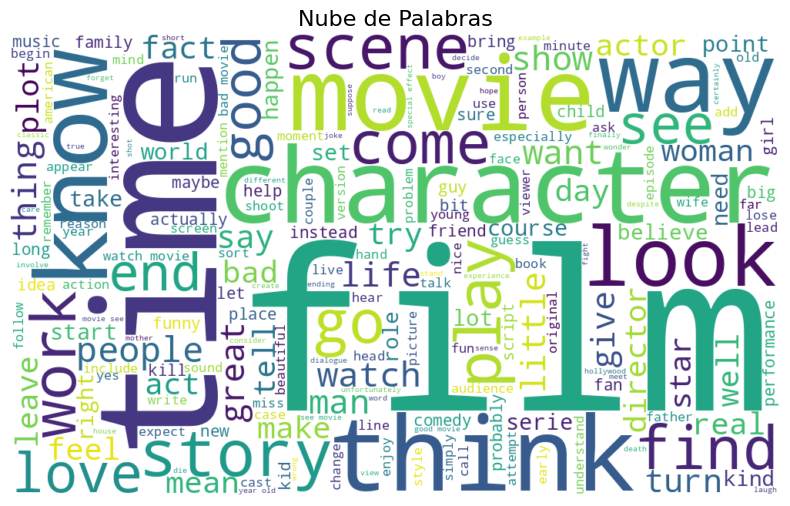

In [133]:
# Nos saltamos el paso de normalizar porque en inglés no existen los acentos

texto_total = " ".join(df["text_clean"].tolist())

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis"
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras", fontsize=16)
plt.show()

In [134]:
df.head()

,split,label,text,rating,id,tokens,text_clean
0,train,1,The Running Man is one of those films that if ...,7,5349,"[run, man, film, overwatche, boring, depressin...",run man film overwatche boring depressing advi...
1,train,1,"This is a great, ridiculous horror movie that ...",9,5973,"[great, ridiculous, horror, movie, capture, es...",great ridiculous horror movie capture essence ...
2,train,1,"I have to agree with MR. Caruso Jr Lanza,s was...",10,10419,"[agree, caruso, lanza, fine, voice, god, offer...",agree caruso lanza fine voice god offer find c...
3,train,1,Something happens to Sondra Pransky when she e...,8,11951,"[happen, sondra, pransky, enter, magician, box...",happen sondra pransky enter magician box stage...
4,train,1,I had never heard of this film prior to seeing...,7,9370,"[hear, film, prior, see, wonder, independent, ...",hear film prior see wonder independent film co...


In [152]:
# Modelo de regresion logistica y Bayes
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Búsqueda de hiper-parametros, train test, metricas
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer

In [140]:
X_train = df.loc[df["split"]=="train", "text_clean"]
y_train = df.loc[df["split"]=="train", "label"]

X_test  = df.loc[df["split"]=="test",  "text_clean"]
y_test  = df.loc[df["split"]=="test",  "label"]

In [153]:
# Vectorizamos

"""tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2), 
    min_df= 0.001,
    max_df=0.7,
    stop_words=None
)"""

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=None,
    lowercase=False,        # ya se hizo .lower()
    stop_words=None,        # ya no hay stopwords
    strip_accents="unicode",
    sublinear_tf=True,
    dtype=np.float32
)

In [154]:
# Ajustamos con el train y transformamos ambos

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [155]:
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape:  {X_test_tfidf.shape}")

Train shape: (25000, 78113)
Test shape:  (25000, 78113)


In [159]:
#Función para evaluación del rendimiento
def evaluate_model(model, X, y, dataset_name="Dataset"):
    y_pred_default = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    #Métricas con umbral 0.5
    acc = accuracy_score(y, y_pred_default)
    sens = recall_score(y, y_pred_default)
    cm = confusion_matrix(y, y_pred_default)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y, y_proba)

    print(f"\n=== Resultados en {dataset_name} (umbral = 0.5) ===")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Sensibilidad:  {sens:.4f}")
    print(f"Especificidad: {spec:.4f}")
    print(f"AUC:           {auc:.4f}")

    #Calibración con J de Youden
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    specificity = 1 - fpr
    J = tpr + specificity - 1
    idx_opt = np.argmax(J)
    best_threshold = thresholds[idx_opt]

    print(f"\n--- Calibración Youden J ---")
    print(f"Umbral óptimo:          {best_threshold:.4f}")
    print(f"Sensibilidad óptima:    {tpr[idx_opt]:.4f}")
    print(f"Especificidad óptima:   {specificity[idx_opt]:.4f}")

    #Recalcular métricas con umbral óptimo
    y_pred_opt = (y_proba >= best_threshold).astype(int)
    acc_opt = accuracy_score(y, y_pred_opt)
    sens_opt = recall_score(y, y_pred_opt)
    cm_opt = confusion_matrix(y, y_pred_opt)
    spec_opt = cm_opt[0,0] / (cm_opt[0,0] + cm_opt[0,1])

    print(f"\n=== Resultados en {dataset_name} (umbral óptimo) ===")
    print(f"Accuracy:      {acc_opt:.4f}")
    print(f"Sensibilidad:  {sens_opt:.4f}")
    print(f"Especificidad: {spec_opt:.4f}")

    #Curva ROC con umbral óptimo
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{dataset_name} (AUC={auc:.4f})", color='blue')
    plt.plot([0,1], [0,1], "k--")
    plt.scatter(fpr[idx_opt], tpr[idx_opt], color='red', label=f"Umbral óptimo={best_threshold:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {dataset_name}")
    plt.legend()
    plt.show()

In [160]:
# Creamos un grid para el mejor alpha
param_grid = {"alpha": np.logspace(-3, 1, 10)}  # valores desde 0.001 hasta 10
grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

,estimator,MultinomialNB()
,param_grid,{'alpha': array([1.0000...00000000e+01])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.46415888336127775


In [161]:
best_alpha = grid.best_params_["alpha"]
print(f"Mejor alfa encontrado: {best_alpha:.4f}")

Mejor alfa encontrado: 0.4642


In [162]:
# Modelo final
nb = MultinomialNB(alpha=best_alpha)
nb.fit(X_train_tfidf, y_train)

,alpha,0.46415888336127775
,force_alpha,True
,fit_prior,True
,class_prior,None


In [163]:
 #Validación cruzada
cv_scores = cross_val_score(nb, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8751
Mediana: 0.8762
Desviación estándar: 0.0022



=== Resultados en Train (umbral = 0.5) ===
Accuracy:      0.9377
Sensibilidad:  0.9405
Especificidad: 0.9350
AUC:           0.9840

--- Calibración Youden J ---
Umbral óptimo:          0.5070
Sensibilidad óptima:    0.9386
Especificidad óptima:   0.9377

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.9381
Sensibilidad:  0.9386
Especificidad: 0.9377


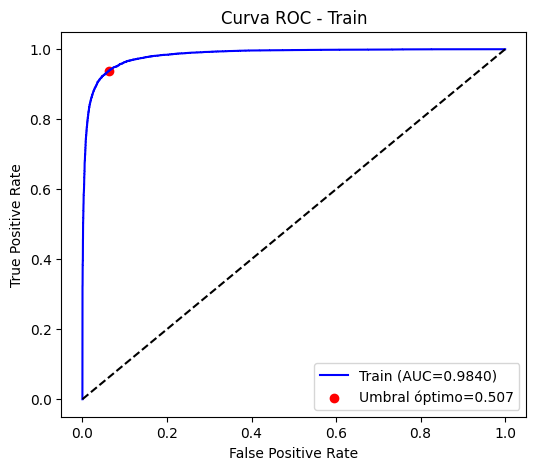


=== Resultados en Test (umbral = 0.5) ===
Accuracy:      0.8505
Sensibilidad:  0.8277
Especificidad: 0.8733
AUC:           0.9289

--- Calibración Youden J ---
Umbral óptimo:          0.4533
Sensibilidad óptima:    0.8643
Especificidad óptima:   0.8434

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8538
Sensibilidad:  0.8643
Especificidad: 0.8434


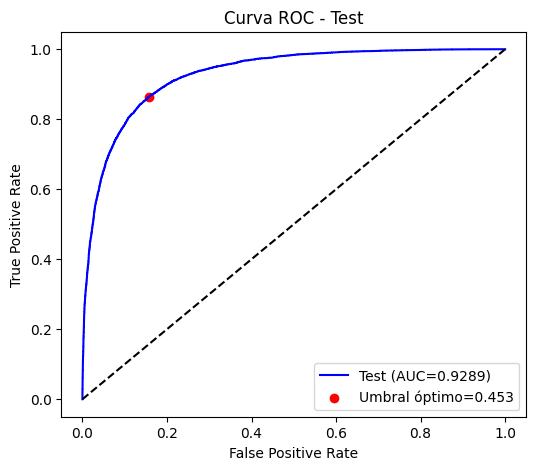

In [164]:
evaluate_model(nb, X_train_tfidf, y_train, "Train")
evaluate_model(nb, X_test_tfidf, y_test, "Test")

In [53]:
X_train, y_train = df.query("split == 'train'").drop('label', axis=1), df.query("split == 'train'").loc[:, 'label']
X_test, y_test = df.query("split == 'test'").drop('label', axis=1), df.query("split == 'test'").loc[:, 'label']

In [70]:
print(clean_text(df.loc[0, 'text']))

The Running Man is one of those films that if overwatched, would become boring and depressing even. My advice is to watch it maybe once or twice a year with a couple of mates and a few drinks. In todays climate of TV Media domination and the capitalist mode in society it really does work as a revisionist social commentary, post 1980s-boom. Forget that though! There are other brilliant and better reasons to watch this film. Schwarzenegger is on top form as Ben "The Butcher of Bakersfield" Richards, and the inclusion of Bond-belting one liners was completely inspired-thety are truly leg-end-dary (with his rant to Killian over a camera the main highlight). The design of the stalkers is authentically American, and mirrors the characterizations seen in the PC 'Gladiators' TV show, and the WWE as well. Buzz-saw's grisly end will chill any viewer to the core (as a foot note, why does his death stand out as particularly disturbing in what is ostensibly an upbeat actioner with a bitter sense of

In [67]:
for i, row in df.loc[:5, ['text']].iterrows():
    print(i, ".", row.iloc[0], end="\n\n")

0 . The Running Man is one of those films that if overwatched, would become boring and depressing even.  My advice is to watch it maybe once or twice a year with a couple of mates and a few drinks.  In todays climate of TV Media domination and the capitalist mode in society it really does work as a revisionist social commentary, post 1980s-boom. Forget that though! There are other brilliant and better reasons to watch this film.  Schwarzenegger is on top form as Ben "The Butcher of Bakersfield" Richards, and the inclusion of Bond-belting one liners was completely inspired-thety are truly leg-end-dary (with his rant to Killian over a camera the main highlight).  The design of the stalkers is authentically American, and mirrors the characterizations seen in the PC 'Gladiators' TV show, and the WWE as well. Buzz-saw's grisly end will chill any viewer to the core (as a foot note, why does his death stand out as particularly disturbing in what is ostensibly an upbeat actioner with a bitter 

# Demanda de ecobicis — Predicción con SVR

* **Datos**: utiliza el dataset **Seoul Bike Sharing Demand** (bicicletas rentadas en Seúl) de UCI ML Repository: [https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand).
* Construye un **modelo de regresión** con **cada uno de los kernels de SVR**, usando como **variable objetivo** `Rented Bike Count`.
* Tras el **análisis de datos**, **encuentra tu mejor modelo** y **compara y concluye**.